In [1]:
from langchain_community.document_loaders import PyPDFLoader

from pdf2image import convert_from_path
import pytesseract

from PIL import Image
import matplotlib.pyplot as plt

import os, time, io

from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage

from dotenv import load_dotenv
load_dotenv()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_13432\1223279294.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader


True

In [ ]:
pdf = r"D:\prac_r\Accenture_AI_ML_Engineer_JD.pdf"
poppler_path = r'C:\Program Files\poppler-26.02.0\Library\bin'

In [3]:
start = time.time()

loader = PyPDFLoader(pdf)
docs = loader.load()

pdf_text = "\n".join(doc.page_content for doc in docs)

end = time.time()

print("=" * 10)
print("PyPDFLoader Results")
print("=" * 10)

print(f"Characters Extracted : {len(pdf_text.strip())}")
print(f"Execution Time       : {end-start:.2f} seconds")

print("\nPreview:\n")
print(pdf_text[:1000])

PyPDFLoader Results
Characters Extracted : 3708
Execution Time       : 0.22 seconds

Preview:

Akshat Agarwal + 91 6375 889353
Roll No.: 23BKT0003 akshatsoftware98@gmail.com
B.Tech - Computer Science and Engineering GitHub | LinkedIn
Vellore Institute of Technology, Vellore
Professional Summar y
Computer Science and Engineering undergraduate at VIT Vellore with interests in Data Science, Machine Learning, and
Artificial Intelligence. Experienced in working with data analysis, machine learning models, and AI-powered applications through
academic and personal projects. Currently pursuing the IIT Madras BS in Data Science and Applications and exploring
Generative AI, RAG systems, and intelligent data-driven solutions.
Educa tion
Degree/Certificate Institute/Board CGPA/Percentage Year
B.Tech. (CSE) Vellore Institute of Technology, Vellore 9.05 / 10 2023 – Present
Senior Secondary (Class XII) Mahapragya International School, Jaipur 92.3% 2022
Secondary (Class X) Mahapragya International Sch

In [4]:
start = time.time()
images = convert_from_path(pdf, poppler_path=poppler_path)
end = time.time()

print(f"Pages: {len(images)}")
print(f"Conversion Time: {end-start:.2f} seconds")


Pages: 1
Conversion Time: 0.20 seconds


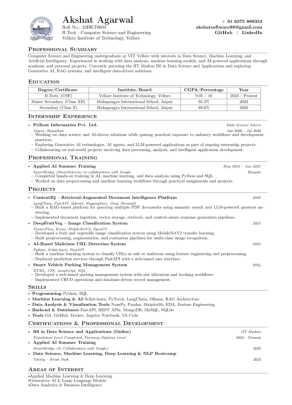

In [5]:
plt.figure(figsize=(8,5))
plt.imshow(images[0])
plt.axis("off")
plt.show()

In [6]:
vision_llm = ChatGroq(
    model="meta-llama/llama-4-scout-17b-16e-instruct",
    api_key= os.getenv("GROQ_API_KEY"),
    temperature=0
)

In [7]:
prompt = """
You are an OCR assistant.

Extract ALL text exactly as it appears in the document.

Rules:

- Preserve headings.
- Preserve bullet points.
- Preserve formatting whenever possible.
- Do NOT summarize.
- Do NOT explain.
- Return only the extracted text.
"""

In [8]:
import base64
import io
import time

full_text = ""

for page_no, image in enumerate(images):

    buffer = io.BytesIO()

    image.save(
        buffer,
        format="PNG"
    )

    image_b64 = base64.b64encode(
        buffer.getvalue()
    ).decode("utf-8")

    message = HumanMessage(
        content=[
            {
                "type": "text",
                "text": prompt
            },
            {
                "type": "image_url",
                "image_url": {
                    "url": f"data:image/png;base64,{image_b64}"
                }
            }
        ]
    )

    response = vision_llm.invoke([message])

    full_text += (
        f"\n\n========== PAGE {page_no+1} ==========\n\n"
    )

    full_text += response.content

    print(
        f"Page {page_no+1} processed."
    )

    time.sleep(5)

print(full_text)

Page 1 processed.


========== PAGE 1 ==========

Akshat Agarwal
Roll No.: 23BKT0003
B.Tech - Computer Science and Engineering
Vellore Institute of Technology, Vellore
+ 91 6375 889353
akshatsoftware98@gmail.com
GitHub | LinkedIn

PROFESSIONAL SUMMARY
Computer Science and Engineering undergraduate at VIT Vellore with interests in Data Science, Machine Learning, and Artificial Intelligence. Experienced in working with data analysis, machine learning models, and AI-powered applications through academic and personal projects. Currently pursuing the IIT Madras BS in Data Science and Applications and exploring Generative AI, RAG systems, and intelligent data-driven solutions.

EDUCATION

| Degree/Certificate | Institute/Board | CGPA/Percentage | Year |
| --- | --- | --- | --- |
| B.Tech. (CSE) | Vellore Institute of Technology, Vellore | 9.05 / 10 | 2023 - Present |
| Senior Secondary (Class XII) | Mahapragya International School, Jaipur | 92.3% | 2022 |
| Secondary (Class X) | Mahapragya I